# 03 — Exploratory Analysis

## Objective

Understand the shape of the data before making comparative or causal-sounding claims: distributions, outliers, and basic descriptive statistics across the 182-country snapshot.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src/visualisation')
snap = pd.read_csv('../data/processed/latest_year_snapshot.csv')
print(f'{len(snap)} countries, {snap["Project_007_Region"].nunique()} regions')
snap[['gdp_per_capita_ppp_current_intl','household_consumption_expenditure_per_capita_constant_2015_usd',
      'consumption_cagr_2013_2023_real_pct','inflation_cpi_annual_pct','internet_users_pct_of_population']].describe()

182 countries, 8 regions


,gdp_per_capita_ppp_current_intl,household_consumption_expenditure_per_capita_constant_2015_usd,consumption_cagr_2013_2023_real_pct,inflation_cpi_annual_pct,internet_users_pct_of_population
count,175.000000,171.000000,171.000000,161.000000,160.000000
mean,31343.318000,8796.148089,2.888954,10.178377,71.170406
std,31307.829409,10142.095411,2.550716,21.307018,26.028447
min,1147.424405,194.426700,-16.441099,-4.644709,7.172300
25%,7077.953313,1589.538265,1.715621,3.642164,57.733125
50%,18540.107908,4258.000864,2.804432,5.879935,81.846578
75%,48660.618065,11196.591175,4.279005,9.283074,91.088578
max,152596.126692,48627.102145,9.358765,221.341644,100.000000


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
import matplotlib.pyplot as plt

ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Distribution of consumption per capita — heavily right-skewed, as expected for a global income-linked variable

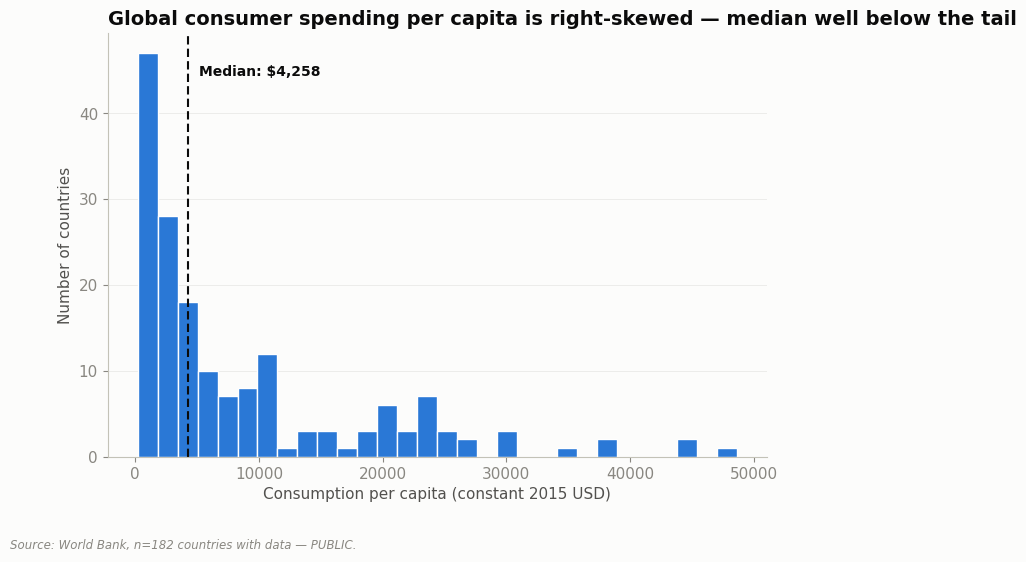

In [3]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(snap['household_consumption_expenditure_per_capita_constant_2015_usd'].dropna(), bins=30, color=ACCENT_1, edgecolor='white')
ax.set_title('Global consumer spending per capita is right-skewed \u2014 median well below the tail', loc='left')
ax.set_xlabel('Consumption per capita (constant 2015 USD)')
ax.set_ylabel('Number of countries')
median_val = snap['household_consumption_expenditure_per_capita_constant_2015_usd'].median()
ax.axvline(median_val, color=INK, linewidth=1.5, linestyle=(0,(4,2)))
ax.annotate(f'Median: ${median_val:,.0f}', xy=(median_val, ax.get_ylim()[1]*0.9), xytext=(8,0), textcoords='offset points', fontsize=10, fontweight='semibold')
add_source(ax.figure, 'Source: World Bank, n=182 countries with data \u2014 PUBLIC.')
plt.show()

## Outlier Check

Countries at the extremes of inflation and growth are flagged here rather than silently winsorised — the analysis downstream (Notebook 05, 06) explicitly discusses how these are handled (e.g. Argentina and Lebanon's hyperinflation years are visible, not hidden, and form their own cluster in Notebook 06).

In [4]:
print('Highest inflation (2013-2023, any year):')
master = pd.read_csv('../data/processed/master_consumer_spending.csv')
print(master.nlargest(8, 'inflation_cpi_annual_pct')[['Country','Year','inflation_cpi_annual_pct']].to_string(index=False))
print('\nFastest consumption CAGR 2013-2023:')
print(snap.nlargest(8, 'consumption_cagr_2013_2023_real_pct')[['Country','consumption_cagr_2013_2023_real_pct']].to_string(index=False))
print('\nSlowest / most negative consumption CAGR 2013-2023:')
print(snap.nsmallest(8, 'consumption_cagr_2013_2023_real_pct')[['Country','consumption_cagr_2013_2023_real_pct']].to_string(index=False))

Highest inflation (2013-2023, any year):
      Country  Year  inflation_cpi_annual_pct
     Zimbabwe  2020                557.201817
  South Sudan  2016                379.999586
        Sudan  2021                359.093041
     Zimbabwe  2019                255.304991
Venezuela, RB  2016                254.948535
      Lebanon  2023                221.341644
  South Sudan  2017                187.851630
      Lebanon  2022                171.205491

Fastest consumption CAGR 2013-2023:
      Country  consumption_cagr_2013_2023_real_pct
      Vanuatu                             9.358765
     Djibouti                             8.638082
     Kiribati                             8.440767
     Ethiopia                             7.476294
   Uzbekistan                             7.434622
        China                             7.134498
   Seychelles                             6.795612
Cote d'Ivoire                             6.777087

Slowest / most negative consumption CAGR 2013-20

## Early Observations

- The global distribution of consumer spending is extremely unequal — a small number of high-income markets sit far above the median, consistent with the regional concentration seen in Notebook 04.
- The fastest-growing and slowest-growing markets are dominated by small or crisis-affected economies at both extremes, not major markets — a reminder that CAGR rankings need market-size context (addressed directly in the market attractiveness matrix, Notebook 07).